# 09. LR·RBF-SVM 초기 모델

266차원 특징으로 두 이진 분류기를 학습한 **2026-09-13 실험 기록**이다. scaler는 Train에서만 맞추고, 임계값은 Validation에서 정해 Test에 적용했다. 뒤의 22·23번 공동 실험과 실행 시점이 다르므로 수치를 섞지 않는다.

In [1]:
from pathlib import Path
import json
import warnings

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.metrics import (
    roc_curve,
    roc_auc_score,
    average_precision_score,
    balanced_accuracy_score,
    f1_score,
    confusion_matrix,
)

PROJECT_ROOT = Path("/Users/seungjae/Desktop/SNU/기계학습 & 딥러닝/project")

FEATURE_PATH = PROJECT_ROOT / "data/processed/features/handcrafted_features_10s.csv"

RESULT_DIR = PROJECT_ROOT / "results/baseline"
MODEL_DIR = PROJECT_ROOT / "checkpoints/baseline"

RESULT_DIR.mkdir(parents=True, exist_ok=True)
MODEL_DIR.mkdir(parents=True, exist_ok=True)

RANDOM_STATE = 42

print("FEATURE_PATH:", FEATURE_PATH)
print("RESULT_DIR  :", RESULT_DIR)
print("MODEL_DIR   :", MODEL_DIR)

FEATURE_PATH: /Users/seungjae/Desktop/SNU/기계학습 & 딥러닝/project/data/processed/features/handcrafted_features_10s.csv
RESULT_DIR  : /Users/seungjae/Desktop/SNU/기계학습 & 딥러닝/project/results/baseline
MODEL_DIR   : /Users/seungjae/Desktop/SNU/기계학습 & 딥러닝/project/checkpoints/baseline


## 1. Feature 데이터 로드

`FAKE = 1`, `REAL = 0`으로 사용한다.

기존 Train / Validation / Test split을 절대 다시 나누지 않는다.

In [2]:
df = pd.read_csv(FEATURE_PATH)

print("===== FEATURE DATA =====")
print("Rows:", len(df))
print("Segments:", df["segment_id"].nunique())

print("\nSplit:")
# 같은 원곡의 표본이 여러 분할에 섞이지 않도록 저장된 split을 그대로 사용한다.
print(df["split"].value_counts())

print("\nLabel:")
print(df["label"].value_counts())

display(df.head())

===== FEATURE DATA =====
Rows: 10077
Segments: 10077

Split:
split
train    6967
test     1572
val      1538
Name: count, dtype: int64

Label:
label
FAKE    9189
REAL     888
Name: count, dtype: int64


,segment_id,track_sample_id,original_audio,label,label_id,source,genre,generator,audio_path,track_id,...,spectral_contrast_05_mean,spectral_contrast_05_std,spectral_contrast_06_mean,spectral_contrast_06_std,spectral_contrast_07_mean,spectral_contrast_07_std,rms_mean,rms_std,zcr_mean,zcr_std
0,seg_000000,sample_00000,"10,000 People Chanting, ""I'm an Individual"" - ...",REAL,0,FMA,Electronic,NaN,data/raw/FMA/selected_30s/140/140932.mp3,140932.0,...,20.978509,3.681772,17.680964,3.077604,45.612125,3.045823,0.168446,0.032360,0.073012,0.026979
1,seg_000001,sample_00000,"10,000 People Chanting, ""I'm an Individual"" - ...",REAL,0,FMA,Electronic,NaN,data/raw/FMA/selected_30s/140/140932.mp3,140932.0,...,21.141379,4.006453,18.433923,3.338184,46.531775,3.344304,0.165984,0.034777,0.065572,0.029458
2,seg_000002,sample_00000,"10,000 People Chanting, ""I'm an Individual"" - ...",REAL,0,FMA,Electronic,NaN,data/raw/FMA/selected_30s/140/140932.mp3,140932.0,...,20.942517,4.096466,18.661063,3.610851,46.294372,4.223743,0.160779,0.034275,0.069711,0.035493
3,seg_000003,sample_00001,1984 - Punk Rock Opera,REAL,0,FMA,Rock,NaN,data/raw/FMA/selected_30s/149/149410.mp3,149410.0,...,16.540522,3.339313,18.091712,2.584768,48.782088,3.142452,0.260969,0.047398,0.091642,0.029509
4,seg_000004,sample_00001,1984 - Punk Rock Opera,REAL,0,FMA,Rock,NaN,data/raw/FMA/selected_30s/149/149410.mp3,149410.0,...,16.824184,3.422880,18.676160,2.789648,50.614979,3.777598,0.239731,0.047017,0.088810,0.029299


## 2. Feature 컬럼 정의

metadata 컬럼을 제외하고 266개의 숫자 feature만 모델 입력으로 사용한다.

In [3]:
FEATURE_COLUMNS = sorted(
    [
        c
        for c in df.columns
        if (
            c.startswith("mfcc_")
            or c.startswith("mfcc_delta_")
            or c.startswith("mfcc_delta2_")
            or c.startswith("spectral_")
            or c.startswith("rms_")
            or c.startswith("zcr_")
        )
    ]
)

print("Feature columns:", len(FEATURE_COLUMNS))

# ID와 행 수가 틀리면 특징·라벨 대응이 어긋나므로 여기서 확인한다.
assert len(FEATURE_COLUMNS) == 266
assert df[FEATURE_COLUMNS].isna().sum().sum() == 0

Feature columns: 266


## 3. Train / Validation / Test 준비

`label_id`를 target으로 사용한다.

- REAL = 0
- FAKE = 1

In [4]:
# 같은 원곡의 표본이 여러 분할에 섞이지 않도록 저장된 split을 그대로 사용한다.
train_df = df[df["split"] == "train"].copy()
val_df = df[df["split"] == "val"].copy()
test_df = df[df["split"] == "test"].copy()

X_train = train_df[FEATURE_COLUMNS].to_numpy(dtype=np.float64)
X_val = val_df[FEATURE_COLUMNS].to_numpy(dtype=np.float64)
X_test = test_df[FEATURE_COLUMNS].to_numpy(dtype=np.float64)

y_train = train_df["label_id"].astype(int).to_numpy()
y_val = val_df["label_id"].astype(int).to_numpy()
y_test = test_df["label_id"].astype(int).to_numpy()

print("===== SHAPES =====")
print("Train:", X_train.shape, y_train.shape)
print("Val  :", X_val.shape, y_val.shape)
print("Test :", X_test.shape, y_test.shape)

print("\nTrain labels:")
print(pd.Series(y_train).value_counts().sort_index())

===== SHAPES =====
Train: (6967, 266) (6967,)
Val  : (1538, 266) (1538,)
Test : (1572, 266) (1572,)

Train labels:
0     621
1    6346
Name: count, dtype: int64


## 4. StandardScaler — Train에서만 fit

Feature마다 수치 범위가 크게 다르므로 scaling이 필요하다.

중요:

```text
Train → fit + transform
Val   → transform only
Test  → transform only
```

Validation / Test 정보를 scaler 학습에 사용하지 않는다.

In [5]:
# 특징마다 범위가 달라 표준화한다. 평균·표준편차는 Train에서만 구한다.
scaler = StandardScaler()

# Train의 평균·표준편차를 구하고 같은 Train 행을 변환한다.
X_train_scaled = scaler.fit_transform(X_train)
# Validation/Test에는 Train의 표준화 기준만 적용해 정보 누수를 막는다.
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

joblib.dump(scaler, MODEL_DIR / "standard_scaler_handcrafted.joblib")

print("Scaler fitted only on Train.")
print("Train scaled mean (approx):", X_train_scaled.mean())
print("Train scaled std  (approx):", X_train_scaled.std())

Scaler fitted only on Train.
Train scaled mean (approx): 1.78668780569304e-18
Train scaled std  (approx): 1.0


## 5. EER Threshold 계산 함수

Validation score에서 다음 두 값을 계산한다.

- FPR: REAL을 FAKE로 잘못 판단한 비율
- FNR: FAKE를 REAL로 놓친 비율

두 값이 가장 가까워지는 threshold를 EER threshold로 선택한다.

이 threshold는 Test에서 다시 조정하지 않는다.

In [6]:
# ROC에서 REAL 오탐과 FAKE 미탐의 균형을 확인한다.
def find_eer_threshold(y_true, scores):
    fpr, tpr, thresholds = roc_curve(
        y_true,
        scores,
        pos_label=1,
    )

    fnr = 1.0 - tpr

    valid = np.isfinite(thresholds)

    fpr_v = fpr[valid]
    fnr_v = fnr[valid]
    thresholds_v = thresholds[valid]

    idx = np.argmin(np.abs(fpr_v - fnr_v))

    eer = (fpr_v[idx] + fnr_v[idx]) / 2.0
    threshold = thresholds_v[idx]

    return {
        "eer": float(eer),
        "threshold": float(threshold),
        "fpr_at_eer": float(fpr_v[idx]),
        "fnr_at_eer": float(fnr_v[idx]),
    }

## 6. Threshold 기반 평가 함수

Validation에서 얻은 threshold를 고정해서 Test 성능을 계산한다.

In [7]:
def evaluate_scores(y_true, scores, threshold):
    y_pred = (scores >= threshold).astype(int)

    roc_auc = roc_auc_score(y_true, scores)
    pr_auc = average_precision_score(y_true, scores)

    bal_acc = balanced_accuracy_score(y_true, y_pred)
    macro_f1 = f1_score(
        y_true,
        y_pred,
        average="macro",
        zero_division=0,
    )

    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()

    real_fpr = fp / (fp + tn) if (fp + tn) > 0 else np.nan
    fake_miss_rate = fn / (fn + tp) if (fn + tp) > 0 else np.nan

    # 현재 split에서의 참고용 EER
    eer_info = find_eer_threshold(y_true, scores)

    return {
        "roc_auc": float(roc_auc),
        "pr_auc": float(pr_auc),
        "eer": float(eer_info["eer"]),
        "threshold_used": float(threshold),
        "balanced_accuracy": float(bal_acc),
        "macro_f1": float(macro_f1),
        "real_fpr": float(real_fpr),
        "fake_miss_rate": float(fake_miss_rate),
        "tn": int(tn),
        "fp": int(fp),
        "fn": int(fn),
        "tp": int(tp),
    }

## 7. Track-level Aggregation 함수

하나의 track에는 1~3개의 10초 segment가 존재한다.

Track-level score는 같은 `track_sample_id`에 속한 segment score의 평균으로 계산한다.

```text
track score
= 해당 track의 segment score 평균
```

In [8]:
# Track-level Aggregation 함수
def make_track_scores(meta_df, scores):
    temp = meta_df[
        [
            "track_sample_id",
            "original_audio",
            "label",
            "label_id",
            "genre",
            "generator",
            "split",
        ]
    ].copy()

    temp["score"] = scores

    track_df = temp.groupby("track_sample_id", as_index=False).agg(
        original_audio=("original_audio", "first"),
        label=("label", "first"),
        label_id=("label_id", "first"),
        genre=("genre", "first"),
        generator=("generator", "first"),
        split=("split", "first"),
        segment_count=("score", "size"),
        score=("score", "mean"),
    )

    return track_df

# Model 0 — Logistic Regression

## 8. Logistic Regression 학습

클래스 불균형을 고려해 `class_weight="balanced"`를 사용한다.

In [9]:
lr_model = LogisticRegression(
    max_iter=3000,
    # 클래스별 표본 수가 달라 손실에 기여하는 비중을 조정한다.
    class_weight="balanced",
    random_state=RANDOM_STATE,
)

# 분류 경계는 Train에만 맞추고 Validation/Test는 선택·평가에 남겨둔다.
lr_model.fit(X_train_scaled, y_train)

joblib.dump(lr_model, MODEL_DIR / "logistic_regression.joblib")

print("Logistic Regression training complete.")

Logistic Regression training complete.


## 9. Logistic Regression — Segment-level 평가

In [10]:
# `predict_proba`로 각 클래스의 예측 확률을 얻는다.
lr_val_scores = lr_model.predict_proba(X_val_scaled)[:, 1]
lr_test_scores = lr_model.predict_proba(X_test_scaled)[:, 1]

# ROC에서 REAL 오탐과 FAKE 미탐의 균형을 확인한다.
# EER은 두 오류율이 같아지는 지점이다. 분류에는 Validation에서 정한 임계값을 쓴다.
lr_segment_val_eer = find_eer_threshold(y_val, lr_val_scores)

lr_segment_threshold = lr_segment_val_eer["threshold"]

print("===== LR SEGMENT VALIDATION EER =====")
print(lr_segment_val_eer)

lr_segment_val_metrics = evaluate_scores(
    y_val,
    lr_val_scores,
    lr_segment_threshold,
)

lr_segment_test_metrics = evaluate_scores(
    y_test,
    lr_test_scores,
    lr_segment_threshold,
)

print("\n===== LR SEGMENT VAL =====")
display(pd.DataFrame([lr_segment_val_metrics]))

print("===== LR SEGMENT TEST =====")
display(pd.DataFrame([lr_segment_test_metrics]))

===== LR SEGMENT VALIDATION EER =====
{'eer': 0.15884844174317858, 'threshold': 0.6663391213946953, 'fpr_at_eer': 0.1590909090909091, 'fnr_at_eer': 0.1586059743954481}

===== LR SEGMENT VAL =====


,roc_auc,pr_auc,eer,threshold_used,balanced_accuracy,macro_f1,real_fpr,fake_miss_rate,tn,fp,fn,tp
0,0.914382,0.989222,0.158848,0.666339,0.841152,0.691454,0.159091,0.158606,111,21,223,1183


===== LR SEGMENT TEST =====


,roc_auc,pr_auc,eer,threshold_used,balanced_accuracy,macro_f1,real_fpr,fake_miss_rate,tn,fp,fn,tp
0,0.877595,0.985322,0.198817,0.666339,0.794618,0.663311,0.244444,0.166319,102,33,239,1198


## 10. Logistic Regression — Track-level 평가

Validation track score에서 별도의 track-level EER threshold를 정한다.
그 threshold를 Test track에 고정 적용한다.

In [11]:
lr_val_track = make_track_scores(val_df, lr_val_scores)

lr_test_track = make_track_scores(test_df, lr_test_scores)

# ROC에서 REAL 오탐과 FAKE 미탐의 균형을 확인한다.
# EER은 두 오류율이 같아지는 지점이다. 분류에는 Validation에서 정한 임계값을 쓴다.
lr_track_val_eer = find_eer_threshold(
    lr_val_track["label_id"].to_numpy(),
    lr_val_track["score"].to_numpy(),
)

lr_track_threshold = lr_track_val_eer["threshold"]

print("===== LR TRACK VALIDATION EER =====")
print(lr_track_val_eer)

lr_track_val_metrics = evaluate_scores(
    lr_val_track["label_id"].to_numpy(),
    lr_val_track["score"].to_numpy(),
    lr_track_threshold,
)

lr_track_test_metrics = evaluate_scores(
    lr_test_track["label_id"].to_numpy(),
    lr_test_track["score"].to_numpy(),
    lr_track_threshold,
)

print("\n===== LR TRACK VAL =====")
display(pd.DataFrame([lr_track_val_metrics]))

print("===== LR TRACK TEST =====")
display(pd.DataFrame([lr_track_test_metrics]))

===== LR TRACK VALIDATION EER =====
{'eer': 0.10754281949934125, 'threshold': 0.6059354207239731, 'fpr_at_eer': 0.11363636363636363, 'fnr_at_eer': 0.10144927536231885}

===== LR TRACK VAL =====


,roc_auc,pr_auc,eer,threshold_used,balanced_accuracy,macro_f1,real_fpr,fake_miss_rate,tn,fp,fn,tp
0,0.962074,0.996056,0.107543,0.605935,0.892457,0.76617,0.113636,0.101449,39,5,49,434


===== LR TRACK TEST =====


,roc_auc,pr_auc,eer,threshold_used,balanced_accuracy,macro_f1,real_fpr,fake_miss_rate,tn,fp,fn,tp
0,0.917634,0.990238,0.138507,0.605935,0.861516,0.752348,0.177778,0.09919,37,8,49,445


# Model 1 — RBF-SVM

## 11. RBF-SVM 학습

`probability=True`를 사용하여 FAKE class probability를 score로 사용한다.

> Logistic Regression보다 학습 시간이 더 오래 걸릴 수 있다.

In [12]:
svm_model = SVC(
    kernel="rbf",
    C=1.0,
    gamma="scale",
    # 클래스별 표본 수가 달라 손실에 기여하는 비중을 조정한다.
    class_weight="balanced",
    probability=True,
    random_state=RANDOM_STATE,
    cache_size=2048,
)

# 분류 경계는 Train에만 맞추고 Validation/Test는 선택·평가에 남겨둔다.
svm_model.fit(X_train_scaled, y_train)

joblib.dump(svm_model, MODEL_DIR / "rbf_svm.joblib")

print("RBF-SVM training complete.")

/opt/anaconda3/envs/stat_env/lib/python3.11/site-packages/sklearn/svm/_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(


RBF-SVM training complete.


## 12. RBF-SVM — Segment-level 평가

In [13]:
# `predict_proba`로 각 클래스의 예측 확률을 얻는다.
svm_val_scores = svm_model.predict_proba(X_val_scaled)[:, 1]
svm_test_scores = svm_model.predict_proba(X_test_scaled)[:, 1]

# ROC에서 REAL 오탐과 FAKE 미탐의 균형을 확인한다.
# EER은 두 오류율이 같아지는 지점이다. 분류에는 Validation에서 정한 임계값을 쓴다.
svm_segment_val_eer = find_eer_threshold(y_val, svm_val_scores)

svm_segment_threshold = svm_segment_val_eer["threshold"]

print("===== SVM SEGMENT VALIDATION EER =====")
print(svm_segment_val_eer)

svm_segment_val_metrics = evaluate_scores(
    y_val,
    svm_val_scores,
    svm_segment_threshold,
)

svm_segment_test_metrics = evaluate_scores(
    y_test,
    svm_test_scores,
    svm_segment_threshold,
)

print("\n===== SVM SEGMENT VAL =====")
display(pd.DataFrame([svm_segment_val_metrics]))

print("===== SVM SEGMENT TEST =====")
display(pd.DataFrame([svm_segment_test_metrics]))

===== SVM SEGMENT VALIDATION EER =====
{'eer': 0.14309345230397863, 'threshold': 0.9258082151422282, 'fpr_at_eer': 0.14393939393939395, 'fnr_at_eer': 0.14224751066856334}

===== SVM SEGMENT VAL =====


,roc_auc,pr_auc,eer,threshold_used,balanced_accuracy,macro_f1,real_fpr,fake_miss_rate,tn,fp,fn,tp
0,0.933524,0.992822,0.143093,0.925808,0.856907,0.712313,0.143939,0.142248,113,19,200,1206


===== SVM SEGMENT TEST =====


,roc_auc,pr_auc,eer,threshold_used,balanced_accuracy,macro_f1,real_fpr,fake_miss_rate,tn,fp,fn,tp
0,0.926158,0.991532,0.147491,0.925808,0.846269,0.711512,0.17037,0.137091,112,23,197,1240


## 13. RBF-SVM — Track-level 평가

In [14]:
svm_val_track = make_track_scores(val_df, svm_val_scores)

svm_test_track = make_track_scores(test_df, svm_test_scores)

# ROC에서 REAL 오탐과 FAKE 미탐의 균형을 확인한다.
# EER은 두 오류율이 같아지는 지점이다. 분류에는 Validation에서 정한 임계값을 쓴다.
svm_track_val_eer = find_eer_threshold(
    svm_val_track["label_id"].to_numpy(),
    svm_val_track["score"].to_numpy(),
)

svm_track_threshold = svm_track_val_eer["threshold"]

print("===== SVM TRACK VALIDATION EER =====")
print(svm_track_val_eer)

svm_track_val_metrics = evaluate_scores(
    svm_val_track["label_id"].to_numpy(),
    svm_val_track["score"].to_numpy(),
    svm_track_threshold,
)

svm_track_test_metrics = evaluate_scores(
    svm_test_track["label_id"].to_numpy(),
    svm_test_track["score"].to_numpy(),
    svm_track_threshold,
)

print("\n===== SVM TRACK VAL =====")
display(pd.DataFrame([svm_track_val_metrics]))

print("===== SVM TRACK TEST =====")
display(pd.DataFrame([svm_track_test_metrics]))

===== SVM TRACK VALIDATION EER =====
{'eer': 0.10754281949934125, 'threshold': 0.8784699961277153, 'fpr_at_eer': 0.11363636363636363, 'fnr_at_eer': 0.10144927536231885}

===== SVM TRACK VAL =====


,roc_auc,pr_auc,eer,threshold_used,balanced_accuracy,macro_f1,real_fpr,fake_miss_rate,tn,fp,fn,tp
0,0.956945,0.99507,0.107543,0.87847,0.892457,0.76617,0.113636,0.101449,39,5,49,434


===== SVM TRACK TEST =====


,roc_auc,pr_auc,eer,threshold_used,balanced_accuracy,macro_f1,real_fpr,fake_miss_rate,tn,fp,fn,tp
0,0.964417,0.996545,0.139541,0.87847,0.869591,0.750198,0.155556,0.105263,38,7,52,442


## 14. 전체 결과 비교표

Validation threshold를 고정 적용한 결과를 하나의 표로 정리한다.

In [15]:
# 전체 결과 비교표
def result_row(model, level, split, metrics):
    return {
        "model": model,
        "level": level,
        "split": split,
        **metrics,
    }


results = pd.DataFrame(
    [
        result_row("LogisticRegression", "segment", "val", lr_segment_val_metrics),
        result_row("LogisticRegression", "segment", "test", lr_segment_test_metrics),
        result_row("LogisticRegression", "track", "val", lr_track_val_metrics),
        result_row("LogisticRegression", "track", "test", lr_track_test_metrics),
        result_row("RBF-SVM", "segment", "val", svm_segment_val_metrics),
        result_row("RBF-SVM", "segment", "test", svm_segment_test_metrics),
        result_row("RBF-SVM", "track", "val", svm_track_val_metrics),
        result_row("RBF-SVM", "track", "test", svm_track_test_metrics),
    ]
)

display(
    results[
        [
            "model",
            "level",
            "split",
            "roc_auc",
            "pr_auc",
            "eer",
            "balanced_accuracy",
            "macro_f1",
            "real_fpr",
            "fake_miss_rate",
            "threshold_used",
        ]
    ].round(4)
)

,model,level,split,roc_auc,pr_auc,eer,balanced_accuracy,macro_f1,real_fpr,fake_miss_rate,threshold_used
0,LogisticRegression,segment,val,0.9144,0.9892,0.1588,0.8412,0.6915,0.1591,0.1586,0.6663
1,LogisticRegression,segment,test,0.8776,0.9853,0.1988,0.7946,0.6633,0.2444,0.1663,0.6663
2,LogisticRegression,track,val,0.9621,0.9961,0.1075,0.8925,0.7662,0.1136,0.1014,0.6059
3,LogisticRegression,track,test,0.9176,0.9902,0.1385,0.8615,0.7523,0.1778,0.0992,0.6059
4,RBF-SVM,segment,val,0.9335,0.9928,0.1431,0.8569,0.7123,0.1439,0.1422,0.9258
5,RBF-SVM,segment,test,0.9262,0.9915,0.1475,0.8463,0.7115,0.1704,0.1371,0.9258
6,RBF-SVM,track,val,0.9569,0.9951,0.1075,0.8925,0.7662,0.1136,0.1014,0.8785
7,RBF-SVM,track,test,0.9644,0.9965,0.1395,0.8696,0.7502,0.1556,0.1053,0.8785


## 15. Test ROC Curve 비교

Segment-level과 Track-level ROC를 각각 비교한다.

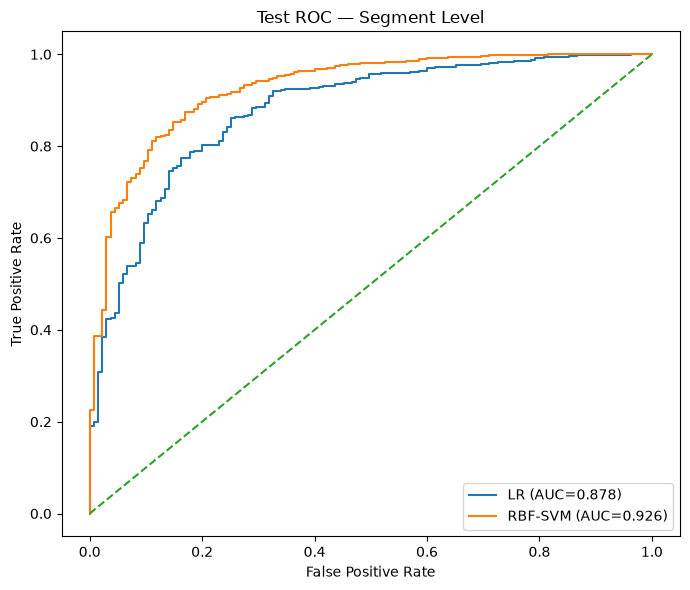

In [16]:
# 임계값을 움직이며 REAL 오탐률(FPR)과 FAKE 탐지율(TPR)을 계산한다.
def plot_roc_curve(y_true, score_dict, title):
    plt.figure(figsize=(7, 6))

    for name, scores in score_dict.items():
        # ROC에서 REAL 오탐과 FAKE 미탐의 균형을 확인한다.
        fpr, tpr, _ = roc_curve(y_true[name], scores)
        auc = roc_auc_score(y_true[name], scores)

        plt.plot(fpr, tpr, label=f"{name} (AUC={auc:.3f})")

    plt.plot([0, 1], [0, 1], linestyle="--")

    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(title)
    plt.legend()
    plt.tight_layout()
    plt.show()


plot_roc_curve(
    {
        "LR": y_test,
        "RBF-SVM": y_test,
    },
    {
        "LR": lr_test_scores,
        "RBF-SVM": svm_test_scores,
    },
    "Test ROC — Segment Level",
)

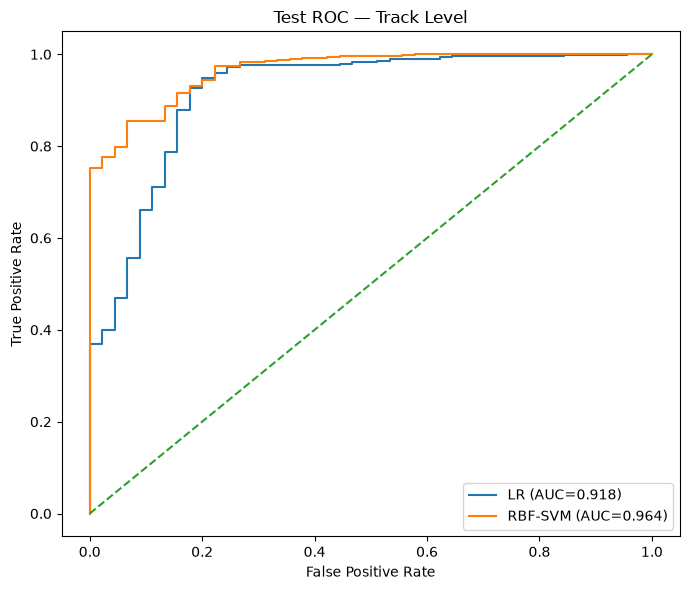

In [17]:
# Test ROC Curve 비교
plot_roc_curve(
    {
        "LR": lr_test_track["label_id"].to_numpy(),
        "RBF-SVM": svm_test_track["label_id"].to_numpy(),
    },
    {
        "LR": lr_test_track["score"].to_numpy(),
        "RBF-SVM": svm_test_track["score"].to_numpy(),
    },
    "Test ROC — Track Level",
)

## 16. Test 예측 결과 저장

향후 generator별 / genre별 / error analysis에 활용할 수 있도록
segment 및 track prediction을 저장한다.

In [18]:
segment_predictions = test_df[
    [
        "segment_id",
        "track_sample_id",
        "original_audio",
        "label",
        "label_id",
        "genre",
        "generator",
        "split",
    ]
].copy()

segment_predictions["lr_score"] = lr_test_scores
segment_predictions["lr_pred"] = (lr_test_scores >= lr_segment_threshold).astype(int)

segment_predictions["svm_score"] = svm_test_scores
segment_predictions["svm_pred"] = (svm_test_scores >= svm_segment_threshold).astype(int)

segment_predictions.to_csv(
    RESULT_DIR / "test_segment_predictions.csv",
    index=False,
    encoding="utf-8-sig",
)


track_predictions = lr_test_track[
    [
        "track_sample_id",
        "original_audio",
        "label",
        "label_id",
        "genre",
        "generator",
        "split",
        "segment_count",
    ]
].copy()

track_predictions["lr_score"] = lr_test_track["score"]
track_predictions["lr_pred"] = (
    track_predictions["lr_score"] >= lr_track_threshold
).astype(int)

svm_track_score_map = dict(
    zip(
        svm_test_track["track_sample_id"],
        svm_test_track["score"],
    )
)

track_predictions["svm_score"] = track_predictions["track_sample_id"].map(
    svm_track_score_map
)

track_predictions["svm_pred"] = (
    track_predictions["svm_score"] >= svm_track_threshold
).astype(int)

track_predictions.to_csv(
    RESULT_DIR / "test_track_predictions.csv",
    index=False,
    encoding="utf-8-sig",
)

print("Saved prediction files.")

Saved prediction files.


## 17. Threshold 및 Metrics 저장

In [19]:
thresholds = {
    "LogisticRegression": {
        "segment_eer_threshold": lr_segment_threshold,
        "track_eer_threshold": lr_track_threshold,
        "segment_val_eer": lr_segment_val_eer["eer"],
        "track_val_eer": lr_track_val_eer["eer"],
    },
    "RBF-SVM": {
        "segment_eer_threshold": svm_segment_threshold,
        "track_eer_threshold": svm_track_threshold,
        "segment_val_eer": svm_segment_val_eer["eer"],
        "track_val_eer": svm_track_val_eer["eer"],
    },
}

with open(RESULT_DIR / "eer_thresholds.json", "w", encoding="utf-8") as f:
    json.dump(
        thresholds,
        f,
        indent=2,
        ensure_ascii=False,
    )

results.to_csv(
    RESULT_DIR / "baseline_metrics.csv",
    index=False,
    encoding="utf-8-sig",
)

print("Saved:", RESULT_DIR / "baseline_metrics.csv")
print("Saved:", RESULT_DIR / "eer_thresholds.json")

Saved: /Users/seungjae/Desktop/SNU/기계학습 & 딥러닝/project/results/baseline/baseline_metrics.csv
Saved: /Users/seungjae/Desktop/SNU/기계학습 & 딥러닝/project/results/baseline/eer_thresholds.json


## 18. 기본 모델 QC

정상적인 baseline 실험이 수행되었는지 최소 조건을 확인한다.

In [20]:
# 기본 모델 QC
qc_summary = pd.DataFrame(
    {
        "check": [
            "feature_columns",
            "train_segments",
            "val_segments",
            "test_segments",
            "train_original_audio",
            "val_original_audio",
            "test_original_audio",
            "lr_segment_threshold_finite",
            "lr_track_threshold_finite",
            "svm_segment_threshold_finite",
            "svm_track_threshold_finite",
            "metrics_rows",
        ],
        "value": [
            len(FEATURE_COLUMNS),
            len(train_df),
            len(val_df),
            len(test_df),
            train_df["original_audio"].nunique(),
            val_df["original_audio"].nunique(),
            test_df["original_audio"].nunique(),
            np.isfinite(lr_segment_threshold),
            np.isfinite(lr_track_threshold),
            np.isfinite(svm_segment_threshold),
            np.isfinite(svm_track_threshold),
            len(results),
        ],
    }
)

display(qc_summary)

baseline_qc_pass = (
    len(FEATURE_COLUMNS) == 266
    and len(train_df) == 6967
    and len(val_df) == 1538
    and len(test_df) == 1572
    and train_df["original_audio"].nunique() == 207
    and val_df["original_audio"].nunique() == 44
    and test_df["original_audio"].nunique() == 45
    and np.isfinite(lr_segment_threshold)
    and np.isfinite(lr_track_threshold)
    and np.isfinite(svm_segment_threshold)
    and np.isfinite(svm_track_threshold)
)

print("===== FINAL RESULT =====")
print("Baseline Core QC PASS:", baseline_qc_pass)

,check,value
0,feature_columns,266
1,train_segments,6967
2,val_segments,1538
3,test_segments,1572
4,train_original_audio,207
5,val_original_audio,44
6,test_original_audio,45
7,lr_segment_threshold_finite,True
8,lr_track_threshold_finite,True
9,svm_segment_threshold_finite,True


===== FINAL RESULT =====
Baseline Core QC PASS: True


## 이어지는 기록

09번의 저장된 점수는 10번에서 생성기·장르별로 나누어 살펴본다.

## 초기 모델 결과

Validation EER threshold를 Test에 고정 적용한 최종 결과다.

| 모델 | 수준 | Test ROC-AUC | Test EER | Balanced Accuracy |
|---|---|---:|---:|---:|
| Logistic Regression | Segment | 0.8776 | 0.1988 | 0.7946 |
| Logistic Regression | Track | 0.9176 | 0.1385 | 0.8615 |
| RBF-SVM | Segment | 0.9262 | 0.1475 | 0.8463 |
| RBF-SVM | Track | **0.9644** | **0.1395** | **0.8696** |

- 두 모델 모두 track aggregation에서 ROC-AUC가 상승했다.
- 대표 handcrafted baseline은 **RBF-SVM Track**으로 선정했다.
- 결과와 고정 threshold, Test 예측을 `results/baseline/`에 저장했다.